# Simulate count data for viral variants

In [36]:
import numpy as np
import pandas as pd

from scipy.optimize import minimize

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

from viral_variant_comp.simulate_count_data import create_count_data
from viral_variant_comp.plotting import plot_viral_composition, plot_confidence_intervals, plot_heatmap
from viral_variant_comp.estimate import calculate_viral_composition, evaluate_result, calculate_viral_composition_stepwise, reorder_variants, calculateHessian, calculate_cooccurence

Assume that on average a new variant arises every 2 weeks: $r = 1/14$ with $\lambda = T \cdot r$. 

If for a variant only 0 counts are sampled, the variant is removed.

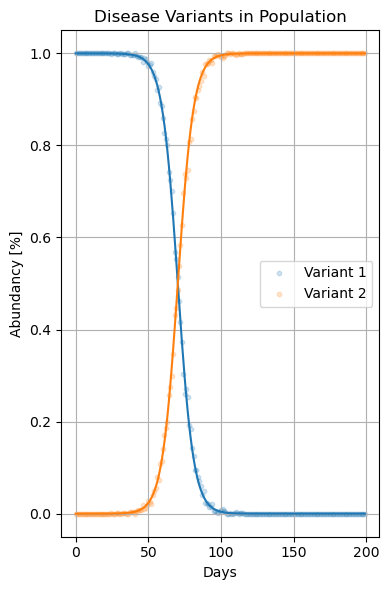

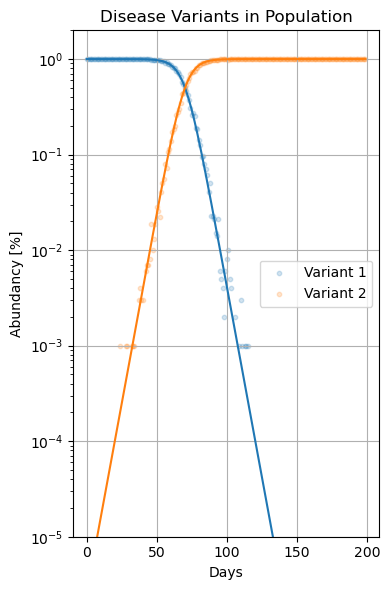

In [57]:
n_variants = 2
n_days = 200
n_samples = 1000

delta_gr_range = 0.2
s_0 = 0.
o_0 = 0.
rate = 1/14  # per day, on average one new variant every two weeks
freq_entering_variants = 0.0001

data = create_count_data(n_variants = n_variants, n_days = n_days, delta_gr_range = delta_gr_range, new_var_rate = rate, freq_entering_variants = freq_entering_variants, n_samples = n_samples, s_0 = s_0, o_0 = o_0)
plot_viral_composition(data['counts'], data['freq'], n_samples, logscale = False)
plot_viral_composition(data['counts'], data['freq'], n_samples, y_range = (1e-5, 2), logscale = True)

#np.savez('data/count_data.npz', **data)
# to reload: np.load('data/count_data.npz')

In [38]:
data.keys()

dict_keys(['growth_rates', 'log_init_freq', 'freq', 'counts', 'n_variants'])

In [39]:
type(data['n_variants'])

numpy.int64

# Use BFGS (Broyden-Fletcher-Goldfarb-Shanno algorithm) to numerically optimize likelihood function

Likelihood function (multinomial distr.):
$$
\mathcal{L}^{(t)}(s,o) = \mathbb{P}(c^{(t)} \mid p^{(t)}) = \frac{N_t!}{\prod_{i=1}^{n} c_i^{(t)}!} \prod_{i=1}^{n} p_i^{(t)^{c_i^{(t)}}}

$$

Log-Likelihood function (over all t):
$$
\log \mathcal{L}(s,o) = \sum_{t=0}^{T} \left( \sum_{i=1}^{n} c_i^{(t)} \cdot \log p_i(t) \right) + \text{const.} = \sum_{t=0}^{T} \sum_{i=1}^{n} c_i^{(t)} \cdot \left[ s_i t + o_i - \log \left( \sum_{j=1}^{n} e^{s_j t + o_j} \right) \right] + \text{const.}
$$

Derivative:
$$
\frac{\partial \log \mathcal{L}(s, o)}{\partial s_i} =
\sum_{t=0}^{T} c_i^{(t)} \cdot t
- \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot t}{\sum_{j=1}^{n} e^{s_j t + o_j}}
$$

$$
\frac{\partial \log \mathcal{L}(s, o)}{\partial o_i} =
\sum_{t=0}^{T} c_i^{(t)} 
- \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i}}{\sum_{j=1}^{n} e^{s_j t + o_j}}
$$

where $N(t) = \sum_{i=0}^{n} c_i^{(t)} $

To avoid not having a clear solution because all parameters are just entering the likelihood as ratios, the growth rate and log. initial frequency of the first variant is fixed to 0.

In [58]:
data_reordered = reorder_variants(data)
result, composition_estimate = calculate_viral_composition(data_reordered['counts'])

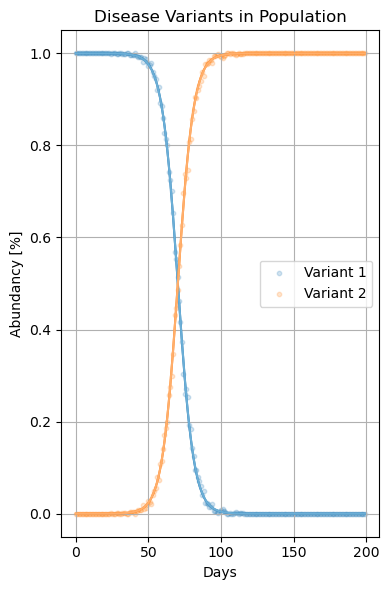

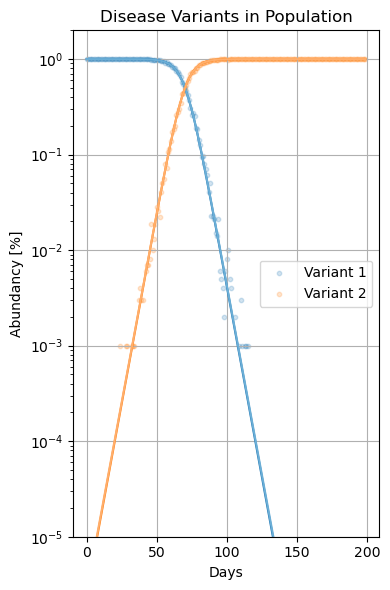

In [59]:
plot_viral_composition(data_reordered['counts'], data_reordered['freq'], n_samples, composition_estimate, logscale = False)
plot_viral_composition(data_reordered['counts'], data_reordered['freq'], n_samples, composition_estimate, y_range = (1e-5, 2), logscale = True)

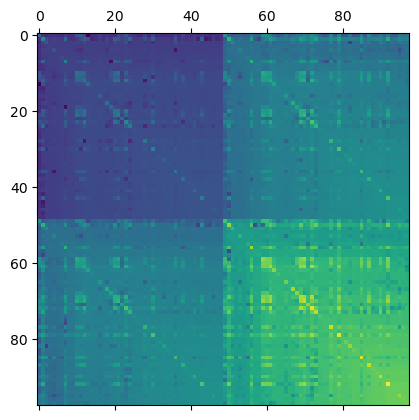

In [42]:
plt.matshow(np.log(np.abs(result.hess_inv)))


# Calculate Hessian

$$
\frac{\partial^2 \log \mathcal{L}(\theta)}{\partial s_i \partial s_j}
= \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot t^2 \cdot e^{s_j t + o_j}}{\left( \sum_{k=1}^{n} e^{s_k t + o_k} \right)^2}
= \sum_{t=0}^{T} N(t) \cdot t^2 \cdot p_i \cdot p_j
$$

$$
\frac{\partial^2 \log \mathcal{L}(\theta)}{\partial s_i^2}
= - \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot t^2 \left( \sum_{j=1}^{n} e^{s_j t + o_j} - e^{s_i t + o_i} \right)}{\left( \sum_{j=1}^{n} e^{s_j t + o_j} \right)^2}
= - \sum_{t=0}^{T} N(t) \cdot t^2 \cdot p_i \cdot (1 - p_i)
$$

$$
\frac{\partial^2 \log \mathcal{L}(\theta)}{\partial o_i \, \partial o_j}
= \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot e^{s_j t + o_j}}{\left( \sum_{k=1}^{n} e^{s_k t + o_k} \right)^2}
= \sum_{t=0}^{T} N(t) \cdot p_i \cdot p_j
$$

$$
\frac{\partial^2 \log \mathcal{L}(\theta)}{\partial o_i^2}
= - \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \left( \sum_{j=1}^{n} e^{s_j t + o_j} - e^{s_i t + o_i} \right)}{\left( \sum_{j=1}^{n} e^{s_j t + o_j} \right)^2}
= - \sum_{t=0}^{T} N(t) \cdot p_i \cdot (1 - p_i)
$$

$$
\frac{\partial^2 \log \mathcal{L}(\theta)}{\partial s_i \, \partial o_j}
= \frac{\partial^2 \log \mathcal{L}(\theta)}{\partial o_i \, \partial s_j} 
= \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot t \cdot e^{s_j t + o_j}}{\left( \sum_{k=1}^{n} e^{s_k t + o_k} \right)^2}
= \sum_{t=0}^{T} N(t) \cdot t \cdot p_i \cdot p_j
$$

$$
\frac{\partial^2 \log \mathcal{L}(\theta)}{\partial s_i \, \partial o_i}
= \frac{\partial^2 \log \mathcal{L}(\theta)}{\partial o_i \, \partial s_i}
= - \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot t \left( \sum_{j=1}^{n} e^{s_j t + o_j} - e^{s_i t + o_i} \right)}{\left( \sum_{j=1}^{n} e^{s_j t + o_j} \right)^2}
= - \sum_{t=0}^{T} N(t) \cdot t \cdot p_i \cdot (1 - p_i)
$$

In [43]:
#counts = data['counts']
#result, composition_estimate = calculate_viral_composition(data['counts'])
#n = counts.shape[1]
#result_hes = calculateHessian(counts, result.x[:n], result.x[n:], ignore_pivot=True)

# Evaluate fit of model

In [44]:
def evaluate_result_new(hess_inv, parameter_estimate, growth_rates, log_init_freq):

    true_params = np.concatenate([growth_rates, log_init_freq])
    print(true_params.shape)
    
    z = 1.96    # 95% confidence interval
    standard_errors =  z * np.sqrt(np.diag(hess_inv))
    lower_bounds = parameter_estimate - standard_errors
    upper_bounds = parameter_estimate + standard_errors

    deviations = result.x - true_params
    abs_deviations = np.abs(deviations)
    estimated_correctly = abs_deviations <= standard_errors

    df = pd.DataFrame({
        'parameter_estimate': parameter_estimate,
        'true_parameter': true_params,
        'deviation': deviations,
        'abs_deviation': abs_deviations,
        'estimated_correctly': estimated_correctly,
        'standard_error': standard_errors,
        'ci_lower': lower_bounds,
        'ci_upper': upper_bounds,
        'n_variants': np.repeat(parameter_estimate.shape[0] // 2, parameter_estimate.shape[0]),
        'parameter_type': np.concatenate([np.repeat('growth_rate', parameter_estimate.shape[0] // 2), np.repeat('log_initial_freq', parameter_estimate.shape[0] // 2)])
    })

    return df

In [45]:
#df_test = evaluate_result_new(neg_inv_hessian, np.concatenate([s_vec, o_vec]), data['growth_rates'], data['log_init_freq'])
#plot_confidence_intervals(df_test)

(100,)


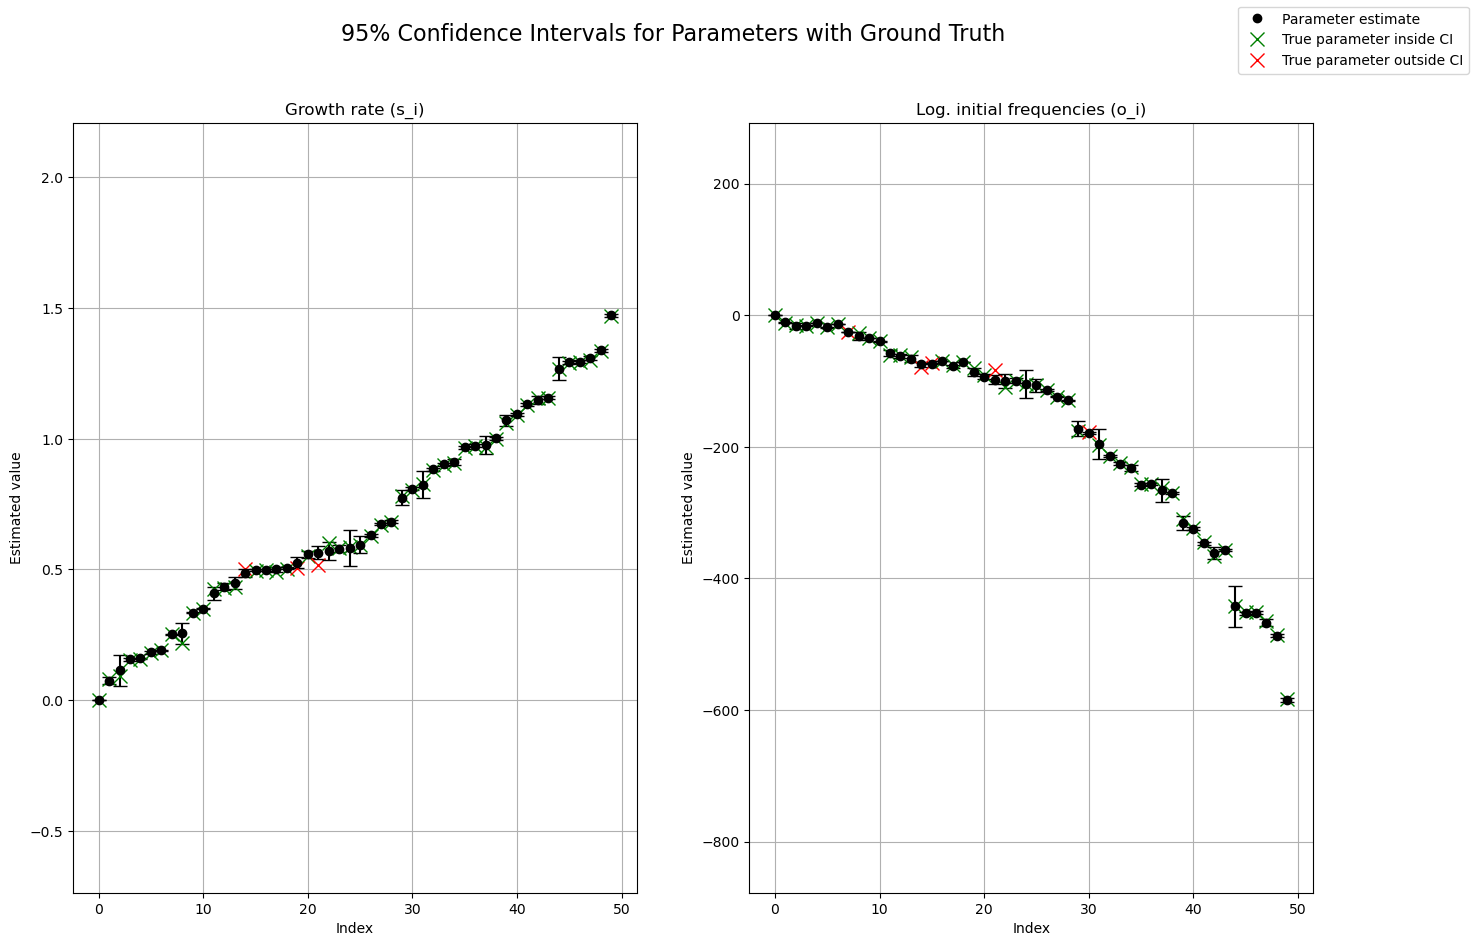

In [46]:
df = evaluate_result(result.x, result.hess_inv, data_reordered['growth_rates'], data_reordered['log_init_freq'])
plot_confidence_intervals(df)

In [47]:
result.hess_inv

array([[ 5.23446668e-05, -4.91083737e-07,  1.94284021e-07, ...,
        -3.15437450e-04, -1.31607075e-04, -1.60750474e-04],
       [-4.91036353e-07,  9.32225716e-04,  2.69606913e-06, ...,
        -1.23382873e-03, -3.46352092e-04, -5.15977721e-04],
       [ 1.94287537e-07,  2.69604496e-06,  1.22848093e-05, ...,
        -1.85666488e-04, -1.63006978e-04, -1.42384855e-04],
       ...,
       [-3.15432961e-04, -1.23389080e-03, -1.85666930e-04, ...,
         7.27880197e+00,  1.19193563e+00,  1.17284002e+00],
       [-1.31602634e-04, -3.46344757e-04, -1.63003469e-04, ...,
         1.19194247e+00,  1.72788627e+00,  1.24815401e+00],
       [-1.60745243e-04, -5.15989400e-04, -1.42381787e-04, ...,
         1.17284526e+00,  1.24815154e+00,  1.87154625e+00]],
      shape=(98, 98))

In [48]:
calculateHessian(data_reordered['counts'], result.x[:result.x.shape[0] // 2], result.x[result.x.shape[0] // 2:], True)['inverse_hessian']

array([[ 3.67607422e-06,  3.57890397e-09, -6.20282070e-10, ...,
        -2.80829256e-09,  3.46760735e-08,  1.28840162e-08],
       [ 3.57890397e-09,  5.44425459e-05, -9.44878328e-10, ...,
        -4.45690507e-09,  5.50327162e-08,  2.04475979e-08],
       [-6.20282070e-10, -9.44878328e-10,  6.44945164e-07, ...,
         5.51470273e-10, -6.80941294e-09, -2.53006116e-09],
       ...,
       [-2.80829256e-09, -4.45690507e-09,  5.51470273e-10, ...,
         2.92927957e-02, -1.55392622e-03, -4.80208027e-04],
       [ 3.46760735e-08,  5.50327162e-08, -6.80941294e-09, ...,
        -1.55392622e-03,  1.05356631e-02,  1.92149928e-03],
       [ 1.28840162e-08,  2.04475979e-08, -2.53006116e-09, ...,
        -4.80208027e-04,  1.92149928e-03,  1.36847344e-03]],
      shape=(98, 98))

# Estimate parameters stepwise

To estimate the parameters more effectively, we can use the fact, that variants, that have been present in the past will not arise again. That's why we can estimate the parameters in a stepwise manner, considering a fixed number of variants at a time.
The variants are ordered according to the timepoint of their peak (average time, weighted by abundance of viral variant). In each estimation step, an overlap size is chosen of variants whose parameter estimates enter the calculation of the next variant. The current algorithm needs at least an overlap of 1 to have one fixed parameter value as a reference.

Currently the variant parameters are estimated the first time they are part of the estimation window and are fixed afterwards.

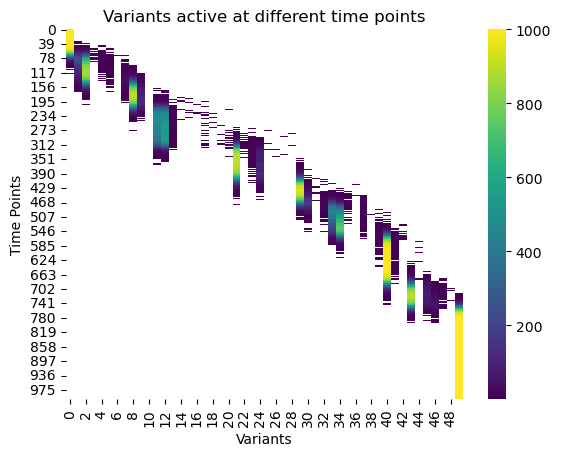

In [49]:
plot_heatmap(data['counts'], "Variants active at different time points", "Variants", "Time Points")

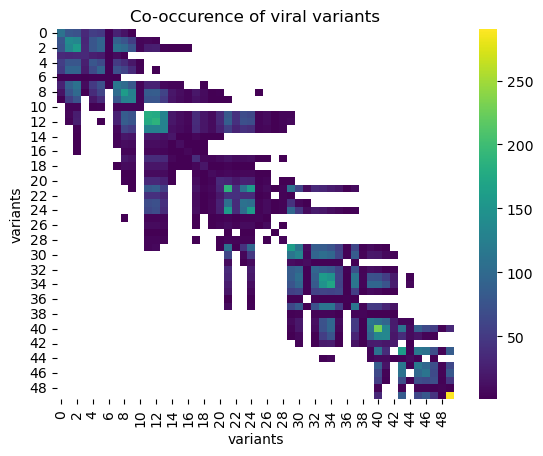

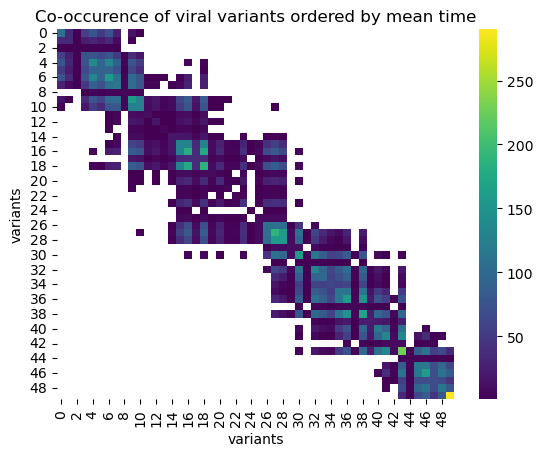

In [50]:
co_occurrence_matrix = calculate_cooccurence(data['counts'])
plot_heatmap(co_occurrence_matrix, "Co-occurence of viral variants", "variants", "variants")

co_occurence_reorderd = calculate_cooccurence(data_reordered['counts'])
plot_heatmap(co_occurence_reorderd, "Co-occurence of viral variants ordered by mean time", "variants", "variants")

Loop  0
Loop  1
Loop  2
Loop  3
Loop  4
Loop  5


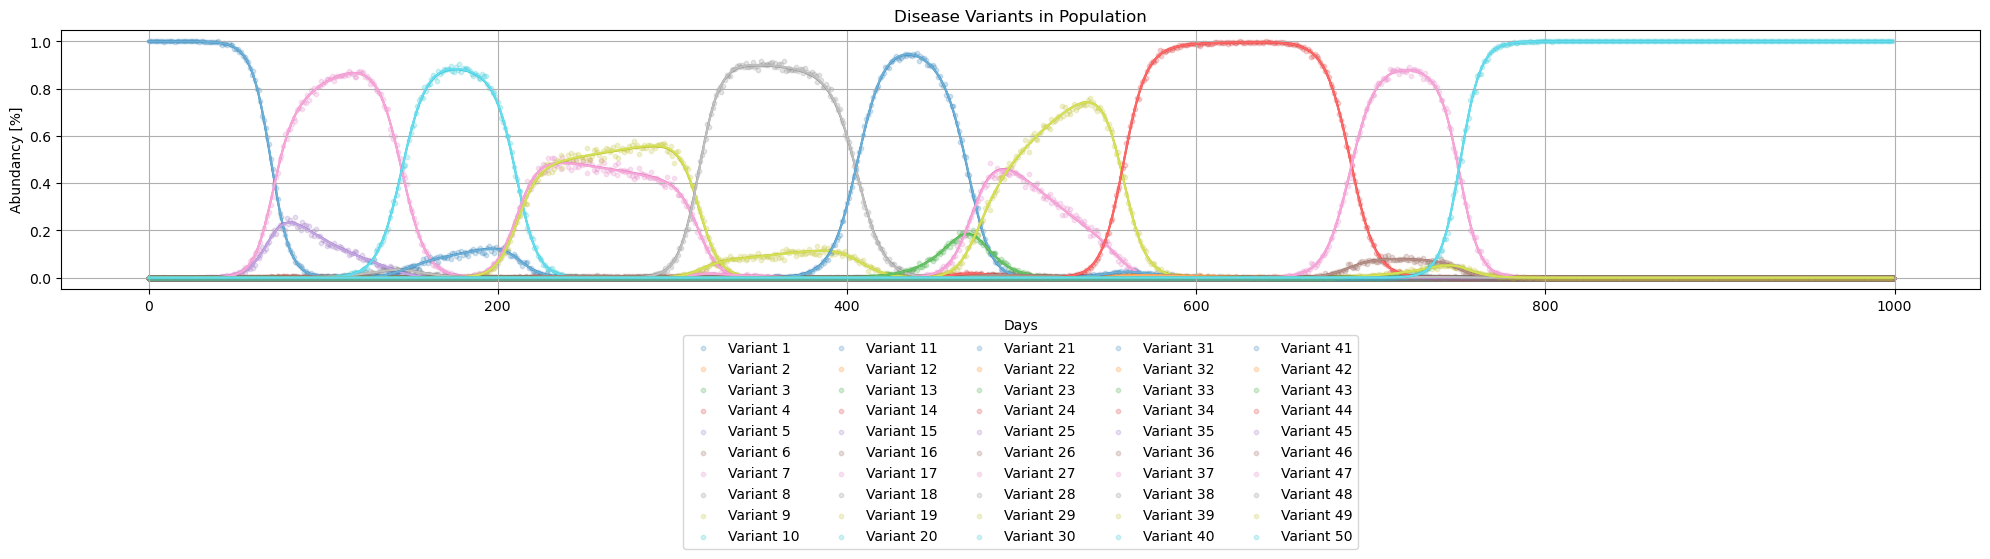

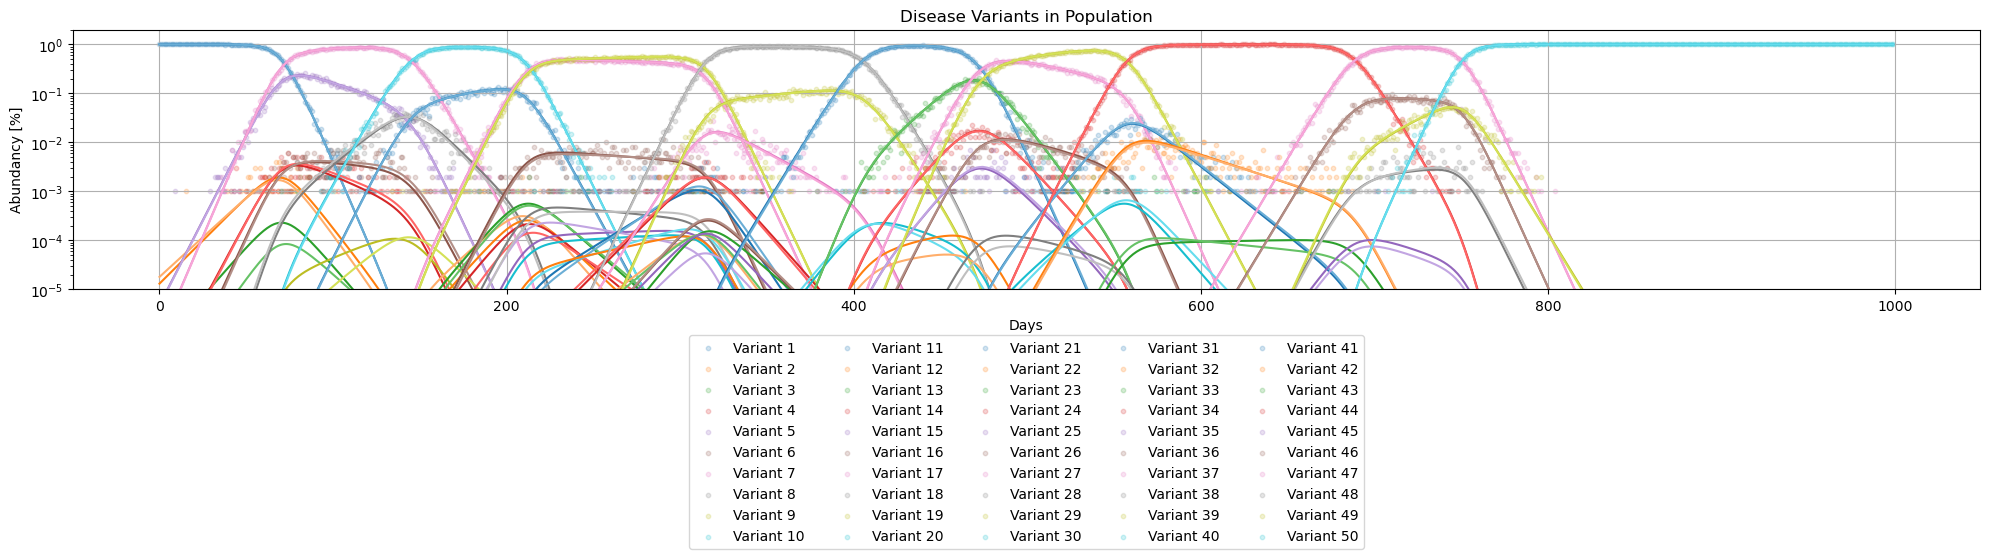

In [51]:
partition_size = 13
overlap_size = 4

result_stepwise = calculate_viral_composition_stepwise(data, partition_size, overlap_size)

plot_viral_composition(result_stepwise['reordered_data']['counts'], result_stepwise['reordered_data']['freq'], n_samples, result_stepwise['composition_estimate'], logscale = False)
plot_viral_composition(result_stepwise['reordered_data']['counts'], result_stepwise['reordered_data']['freq'], n_samples, result_stepwise['composition_estimate'], y_range = (1e-5, 2), logscale = True)

(100,)


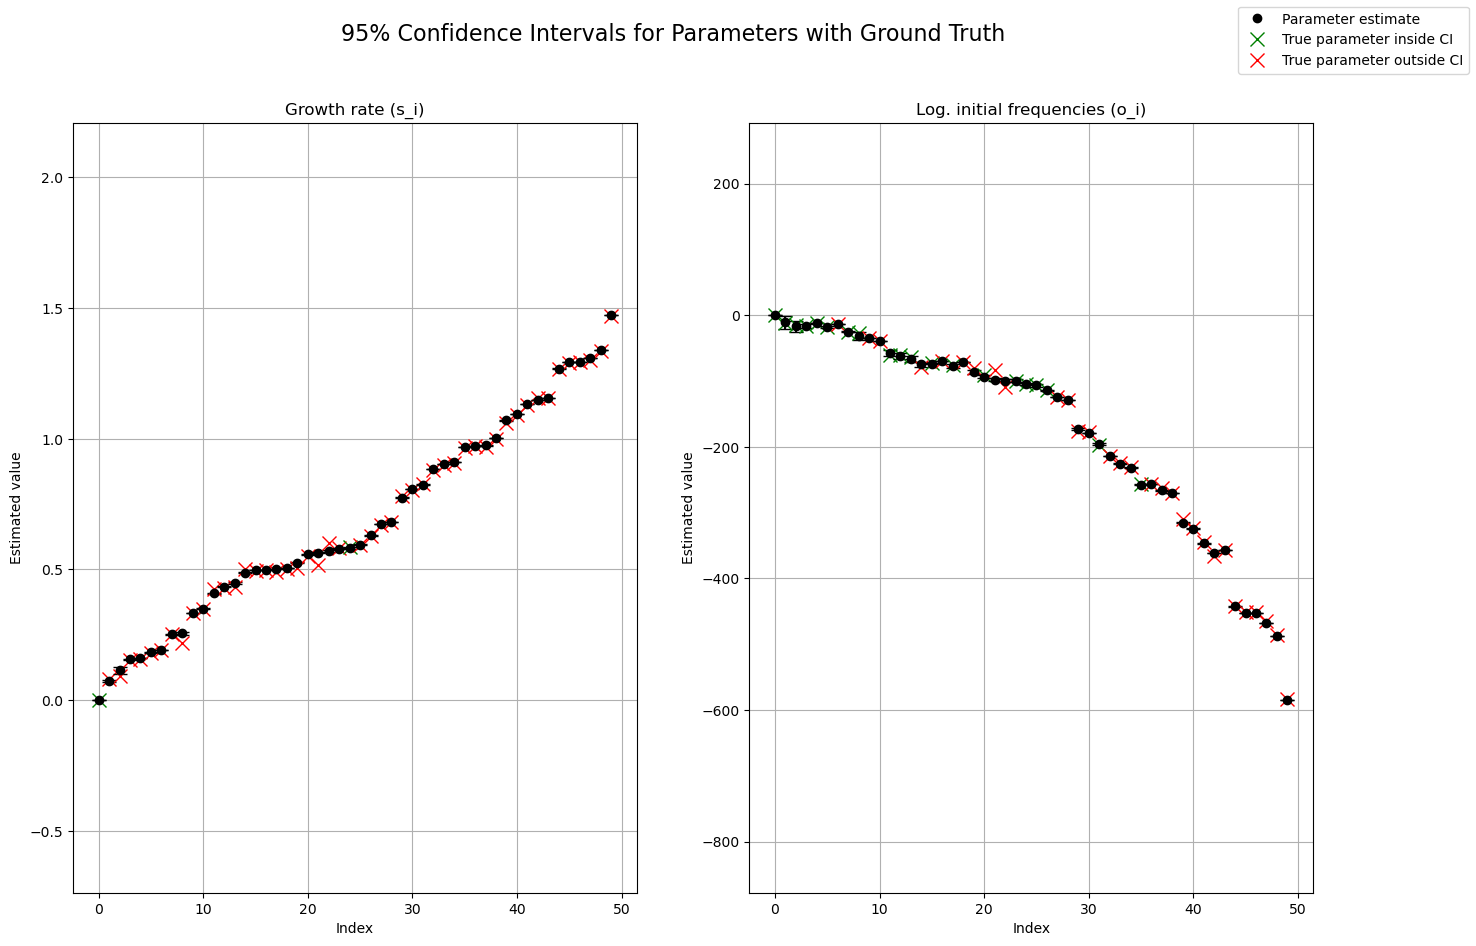

In [53]:
df = evaluate_result(np.concatenate([result_stepwise['growth_rate_estimate'], result_stepwise['log_init_freq_estimate']]), np.abs(result_stepwise['hess_inv']), data_reordered['growth_rates'], data_reordered['log_init_freq'])
plot_confidence_intervals(df)

In [54]:
np.diag(result_stepwise['hess_inv'])

array([3.67608350e-06, 5.44420820e-05, 6.44945650e-07, 1.10271331e-08,
       2.95747433e-07, 5.39969976e-09, 3.52476111e-08, 9.72538506e-06,
       2.01365897e-09, 4.54036642e-09, 1.91949935e-06, 1.05860911e-06,
       3.34664691e-06, 9.36936072e-07, 2.68412630e-08, 5.10133331e-10,
       3.57116278e-07, 4.84112961e-10, 1.21283532e-06, 2.11063327e-07,
       2.11463806e-06, 2.08825046e-06, 1.43904340e-07, 5.08321134e-06,
       9.90134741e-07, 1.30426782e-08, 3.95384240e-10, 8.72293577e-10,
       5.14232097e-07, 3.42875819e-10, 1.69361788e-06, 7.26833600e-10,
       6.92464117e-09, 3.61732147e-08, 6.00499479e-09, 1.96293563e-10,
       7.87697467e-07, 1.60707911e-10, 1.24399634e-07, 3.12011806e-09,
       4.67399437e-09, 2.43983986e-07, 1.78695666e-10, 5.10957666e-07,
       4.12281235e-10, 1.18962596e-10, 1.09961591e-08, 8.59757238e-10,
       3.04567026e-10, 2.34502931e+01, 1.72682763e+01, 2.64577902e+00,
       7.46512379e-04, 8.10398005e-01, 6.26626487e-05, 1.39578464e-01,
      

In [55]:
np.linalg.eig(result_stepwise['hessian'])

EigResult(eigenvalues=array([ 1.14909819e+10,  9.55115286e+09,  4.99398299e+09,  4.04089826e+09,
        3.59018193e+09,  3.02474536e+09,  2.47750315e+09,  1.92224516e+09,
        1.43487350e+09,  8.78350096e+08,  7.03980916e+08,  5.07646253e+08,
        3.51383068e+08,  2.67502380e+08,  2.58464147e+08,  2.23698612e+08,
        1.68633280e+08,  1.45784919e+08,  1.09776983e+08,  9.29215760e+07,
        7.00555167e+07,  4.88483906e+07,  3.58506398e+07,  2.90301557e+07,
        2.26863126e+07,  9.04780397e+06, -4.76806488e+06,  7.31964177e+06,
        5.86449249e+06,  4.53412205e+06,  3.96101392e+06,  3.25949108e+06,
        2.75039759e+06,  1.98531081e+06,  1.93175318e+06,  1.53077183e+06,
        1.27503048e+06,  1.06418938e+06,  1.00841098e+06,  9.42021228e+05,
        8.23114739e+05, -3.48076280e+05,  5.92383551e+05,  5.20387168e+05,
        2.71911294e+05,  2.98716038e+05,  4.78900634e+05,  4.72829840e+05,
        1.97194718e+05,  1.02815977e+05, -7.57847397e+04, -4.06407684e+04,
   

A high variance and oftentimes inaccurate parameter estimates are observed when a variant doesn't appear a lot in the data. Usually it only contains 1 count at a few time points.